# Assess Global NetCDF Output
Load `LLC4320_2012-09-11T12_00_00_Divb2.nc` and `LLC4320_grid.nc`, then plot divergence of buoyancy gradient (log_gradb) on a global map using lat/lon from the grid file.

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [8]:
DATA_DIR = "/mnt/tank/Oceanography/data/OGCM/LLC/Fronts"

ds_data = xr.open_dataset(f"{DATA_DIR}/vtest/20121109_120000/LLC4320_2012-11-09T12_00_00_N2_sfc.nc")
ds_grid = xr.open_dataset(f"{DATA_DIR}/coords/LLC_coords_lat_lon.nc")

print("Data file:")
print(ds_data)
print("\nGrid file:")
print(ds_grid)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/vtest/20121109_120000/LLC4320_2012-11-09T12_00_00_N2_sfc.nc'

In [4]:
# Extract lat/lon from grid
lon = ds_grid["XC"].values if "XC" in ds_grid else ds_grid["lon"].values
lat = ds_grid["YC"].values if "YC" in ds_grid else ds_grid["lat"].values

# Extract divb2 (log_gradb) — shape (H, W) or (1, H, W)
data_var = list(ds_data.data_vars)[0]
field = ds_data[data_var].values
if field.ndim == 3:
    field = field[0]  # drop time dim if present

print(f"Variable: {data_var}")
print(f"Field shape: {field.shape}, lon shape: {lon.shape}, lat shape: {lat.shape}")

Variable: N2_sfc
Field shape: (12960, 17280), lon shape: (12960, 17280), lat shape: (12960, 17280)


In [5]:
# Downsample for fast plotting
DS = 20
lon_ds = lon[::DS, ::DS]
lat_ds = lat[::DS, ::DS]
field_ds = field[::DS, ::DS]

print(f"Downsampled shape: {field_ds.shape}")

Downsampled shape: (648, 864)


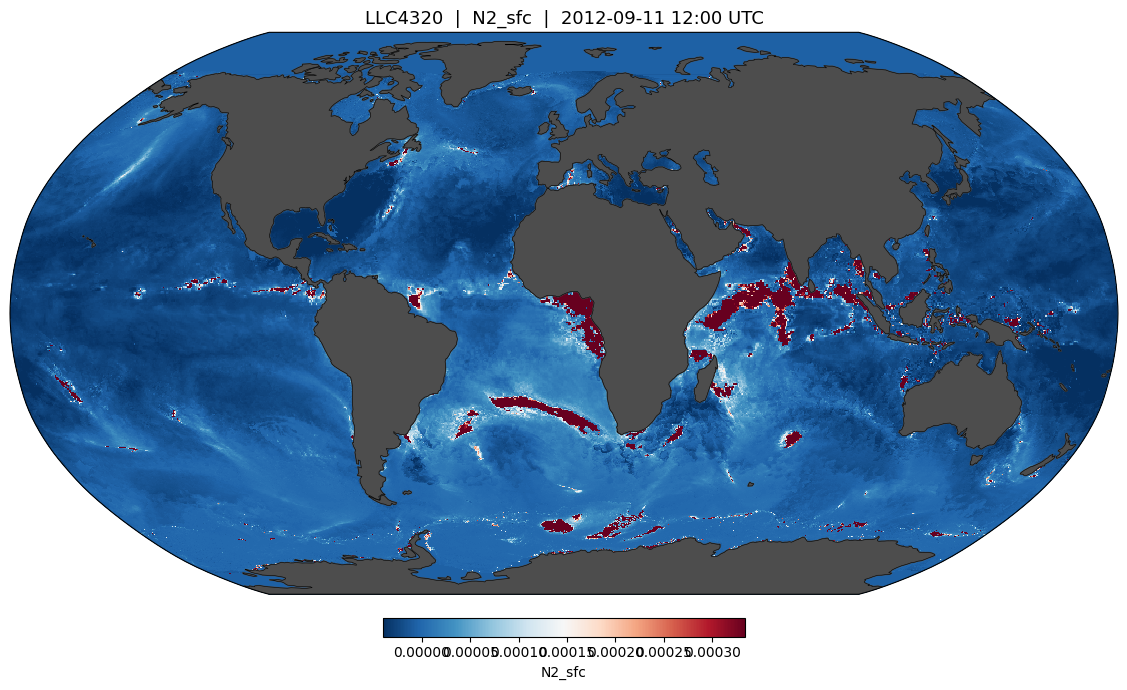

In [6]:
# Percentile-based colour limits (robust to outliers)
vmin, vmax = np.nanpercentile(field_ds, [2, 98])

fig, ax = plt.subplots(
    figsize=(14, 7),
    subplot_kw={"projection": ccrs.Robinson()}
)
ax.set_global()
ax.add_feature(cfeature.LAND, color="0.3", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=2)

pcm = ax.pcolormesh(
    lon_ds, lat_ds, field_ds,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin, vmax=vmax,
    shading="auto",
    rasterized=True,
    zorder=0
)

plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.04,
             fraction=0.03, label=data_var)

ax.set_title(f"LLC4320  |  {data_var}  |  2012-09-11 12:00 UTC", fontsize=13)
plt.tight_layout()
plt.show()